In [ ]:
import requests
from bs4 import BeautifulSoup

def scrape_jumia_products(search_term):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }

    url = f"https://www.jumia.com.ng/catalog/?q={search_term}%20laptop"
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')
    laptop=[]
    products = soup.find_all('article', {'class': 'prd _fb col c-prd'})
    print(f"Found {len(products)} products for '{search_term}':\n")
    for product in products:
        name_tag = product.find('h3', class_='name')
        price_tag = product.find('div', class_='prc')
        #link_tag = product.find('a', href=True)
        name = name_tag.text.strip() if name_tag else "N/A"
        price = price_tag.text.strip() if price_tag else "N/A"
        #ink = "https://www.jumia.com.ng" + link_tag['href'] if link_tag else "N/A"
        laptop.append({"Description":name,'Price':price,'Model':search_term})
    return laptop


In [ ]:
def Catalogue(AccessoriesName):
    Accessories=[]
    for laptopType in AccessoriesName:
        newLaptop=scrape_jumia_products(laptopType)
        Accessories.extend(newLaptop)
    return Accessories



In [ ]:
def scrape_jumia_products2(search_term):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }
    url = f"https://www.jumia.com.ng/catalog/?q={search_term}%20laptop"
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')
    laptop=[]
    products = soup.find_all('article', {'class': 'prd _fb col c-prd'})
    #print(f"Found {len(products)} products for '{search_term}':\n")
    for product in products:
        name_tag = product.find('h3', class_='name')
        price_tag = product.find('div', class_='prc')
        #rate_tag=product.find('div',class_='stars_s')  #if review_tag else "N/A"
       
        #link_tag = product.find('a', href=True)
        name = name_tag.text.strip() if name_tag else "N/A"
        #review = rate_tag.text.strip() if rate_tag else "N/A"
        price = price_tag.text.strip() if price_tag else "N/A"
        price=price.replace(',','').replace(' ','').replace('₦','')
        #ink = "https://www.jumia.com.ng" + link_tag['href'] if link_tag else "N/A"
        if '-' not in price:
            laptop.append({"Description":name,'Price':int(price),'Model':search_term}) 
    return laptop

def Catalogue2(AccessoriesName):
    Accessories=[]
    for laptopType in AccessoriesName:
        newLaptop=scrape_jumia_products2(laptopType)
        Accessories.extend(newLaptop)
    return Accessories

In [ ]:
import pandas as pd
List=['hp','ace','dell','macbook','lenovo','samsong','toshiba','huawei','seagate','apple','asus','microsoft']
Laptop=pd.DataFrame(Catalogue2(List))
Laptop.head

In [ ]:
import matplotlib.pyplot as plt
#data=Laptop.groupby('Model').agg({'Price': ['mean', 'max','min','count']})
#Laptop.to_excel("JumiaLaptop.xlsx", index=False)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Excel file (change the path to your actual file)
file_path = "JumiaLaptop.xlsx"

# Read Excel into DataFrame
df = pd.read_excel(file_path, sheet_name='Sheet1')

# Remove extreme outliers (e.g., less than ₦5,000 or above ₦5,000,000)
Laptop= df[(df['Price'] >= 5000) & (df['Price'] <= 5000000)]

# Plot price distribution

In [20]:
def PlotHist(df):
    plt.figure(figsize=(12, 8))
    
    i=1
    for model in List:
        filtered_df = df[df['Model'] ==model]
        plt.subplot(3,3,i)
        sns.histplot(filtered_df['Price'], bins=6, kde=True, color='skyblue')
        plt.title(f"{model} Laptop ", fontsize=14)
        plt.xlabel("Price (₦)")
        plt.ylabel("Number of Listing")
        i=i+1
        #plt.grid(True)
        plt.subplots_adjust(left=0.1,right=0.9,bottom=0.1,top=0.9,hspace=0.8,wspace=0.4)
    plt.suptitle('Price Distribution of Laptop on Jumia')
    plt.show()

def PlotBox(df):
    plt.figure(figsize=(10, 7))
    
    i=1
    for model in List:
        filtered_df = df[df['Model'] ==model]
        plt.subplot(2,4,i)
        sns.boxplot(filtered_df['Price'],color="#ff33f5")
        plt.title(f"{model} Laptop ", fontsize=14)
        plt.ylabel("Price (₦)")
        i=i+1
        #plt.grid(True)
        plt.subplots_adjust(left=0.1,right=0.9,bottom=0.1,top=0.9,hspace=0.3,wspace=0.4)
    plt.suptitle('Price Distribution of Laptop on Jumia')
    plt.show()



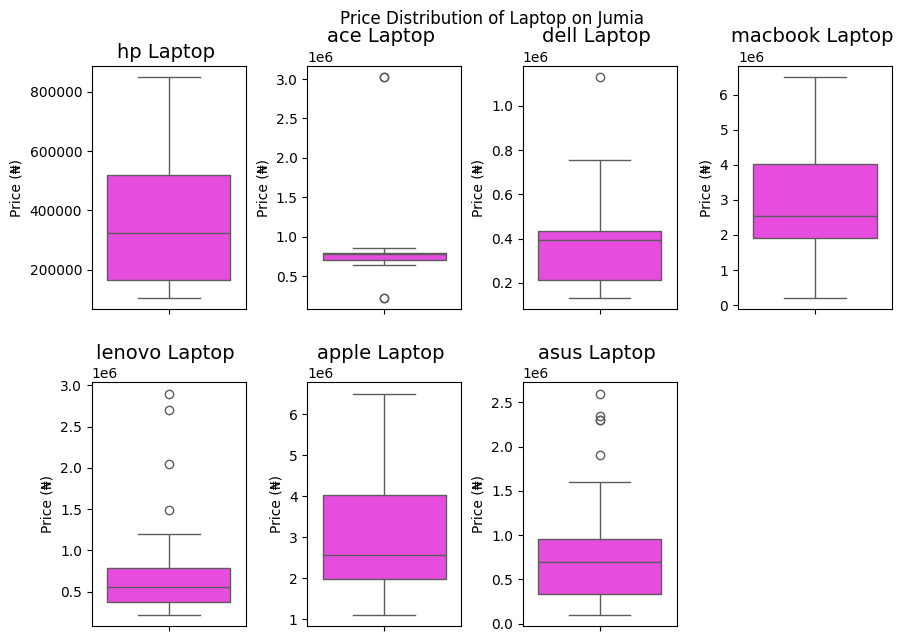

In [24]:
# Load Excel file (change the path to your actual file)
file_path = "JumiaLaptop.xlsx"
# Read Excel into DataFrame
df = pd.read_excel(file_path, sheet_name='Sheet1')
Laptop=df
List=['hp','ace','dell','macbook','lenovo','apple','asus',]
Laptop=Laptop[(Laptop['Model']!='seagate') & (Laptop['Model']!='samsong')& (Laptop['Model']!='toshiba')&(Laptop['Model']!='microsoft')&(Laptop['Model']!='huawei')]
Laptop=Laptop[Laptop['Price']>90000]
PlotBox(Laptop)
#PlotHist(Laptop)

In [4]:
def scrape_jumia_Phone(search_term):
    import requests
    from bs4 import BeautifulSoup
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }
    url = f"https://www.jumia.com.ng/smartphones/{search_term}"
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')
    laptop=[]
    products = soup.find_all('article', {'class': 'prd _fb col c-prd'})
    #print(f"Found {len(products)} products for '{search_term}':\n")
    for product in products:
        name_tag = product.find('h3', class_='name')
        price_tag = product.find('div', class_='prc')
        #rate_tag=product.find('div',class_='stars_s')  #if review_tag else "N/A"
       
        #link_tag = product.find('a', href=True)
        name = name_tag.text.strip() if name_tag else "N/A"
        #review = rate_tag.text.strip() if rate_tag else "N/A"
        price = price_tag.text.strip() if price_tag else "N/A"
        price=price.replace(',','').replace(' ','').replace('₦','')
        #ink = "https://www.jumia.com.ng" + link_tag['href'] if link_tag else "N/A"
        if '-' not in price:
            laptop.append({"Description":name,'Price':int(price),'Model':search_term}) 
    return laptop

def CataloguePhone(AccessoriesName):
    Accessories=[]
    for laptopType in AccessoriesName:
        newLaptop=scrape_jumia_Phone(laptopType)
        Accessories.extend(newLaptop)
    return Accessories


In [ ]:
List=['AGM','Amazona','Apple','Archos','Atouch','Bebe','BEBE TAB','Blackberry','Blackview','Bontel','Byd','Canon Ink Cart','C Idea','Cmf','Danew','Discover','ECOFLOW','FHUK','Fire','FOSSiBOT','FreeYond','FYLO','Galaxy','GENIUS KIDS','Gionee','Google','Google Pixel','Graphite','Hauwei','Hmd','Honor','Huawei','Infinix','Innjoo','itel','Lenovo','Letv','LG','Mi','Microsoft','MKTEL','Moto','Motorola','Nokia','Nothing','Nubia','Oneplus','Oppo','Oukitel','Panasonic','Philips','Poco','POOLEE','Realme','redbeat','Renewed','Samsung','SanDisk','SHOW','SML','Sovo','Tecno','Texas Instruments','Thuraya','TRIFONE','UMIDIGI','VILLAON','Vivo','XIAOMI']
J=CataloguePhone(List[:9])

In [ ]:
len(J)

[{'Description': 'AGM Note N1 6.52"  8GB Base RAM/8GB Extended RAM/128GB ROM Android 13 - Grey',
  'Price': 127625,
  'Model': 'AGM'},
 {'Description': 'AGM Note N1 6.52" 8GB Base RAM/8GB Extended RAM/128GB ROM Android 13- Blue',
  'Price': 127190,
  'Model': 'AGM'},
 {'Description': 'AGM AGM H MAX 4G Rugged Smartphone Android 14 10000mAh 8(4+4)GB+128GB',
  'Price': 198000,
  'Model': 'AGM'},
 {'Description': 'AGM H6 Leather Ultra-Thin Rugged Smartphone 6.6" 16GB RAM/256GB Android 13 NFC - Orange',
  'Price': 234900,
  'Model': 'AGM'},
 {'Description': 'AGM H6 Leather Lite Ultra-Thin Rugged Smartphone 6.6" 4GB RAM/128GB Android 13 NFC - Black',
  'Price': 194387,
  'Model': 'AGM'},
 {'Description': 'AGM M10 FLIP, 2.4", 4G Rugged Phone, Waterproof, LED Torch',
  'Price': 74208,
  'Model': 'AGM'},
 {'Description': 'AGM H6 6.6", 256GB ROM /16GB RAM Android 13 - Black',
  'Price': 290806,
  'Model': 'AGM'},
 {'Description': 'AGM H6 Leather Ultra-Thin Rugged Smartphone 6.6" 16GB RAM/256GB A